In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam

In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: None -- [Errno 11001] getaddrinfo failed

In [ ]:
mnist.info()

In [3]:
print(type(x_train))
print(x_train.shape)

<class 'numpy.ndarray'>
(60000, 28, 28)


In [4]:
print('Training data shape   : ', x_train.shape)
print('Training labels shape : ', y_train.shape)
print('Testing data shape    : ', x_test.shape)
print('Testing labels shape  : ', y_test.shape)

Training data shape   :  (60000, 28, 28)
Training labels shape :  (60000,)
Testing data shape    :  (10000, 28, 28)
Testing labels shape  :  (10000,)


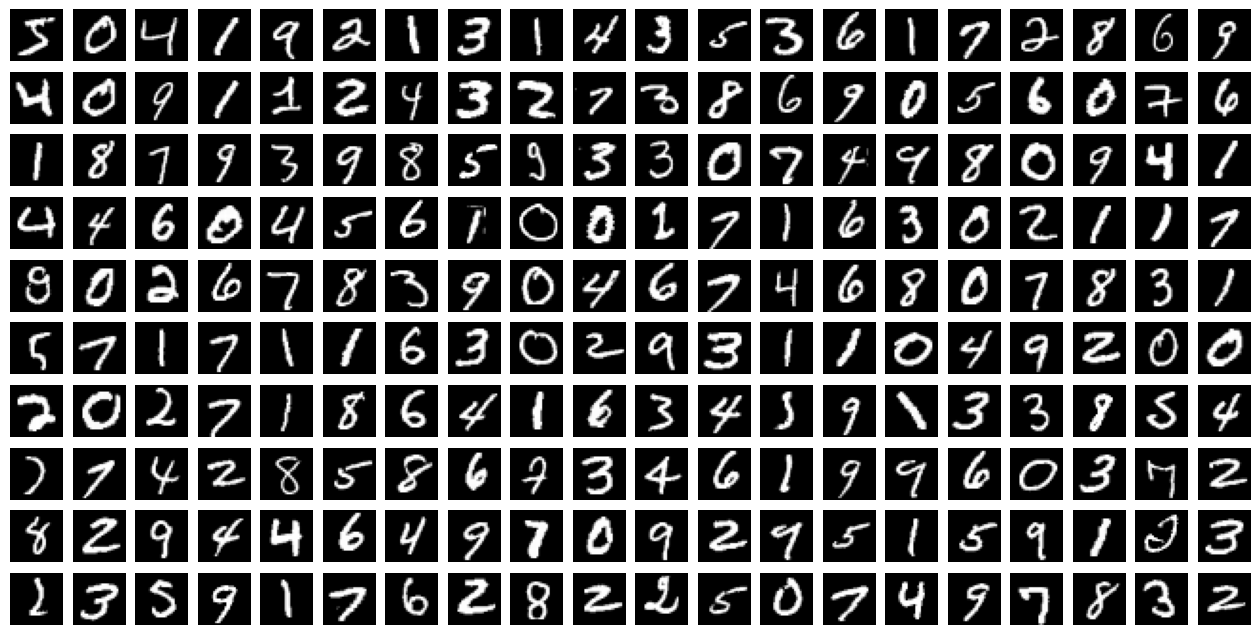

In [5]:
plt.figure(figsize = (16,8))
for i in range(200):
  plt.subplot(10,20,i+1)
  plt.axis('off')
  plt.imshow(x_train[i], cmap = 'gray')

In [6]:
from keras.utils.np_utils import to_categorical
y_train = to_categorical(y_train, num_classes = 10)
y_test  = to_categorical(y_test,  num_classes = 10)

print('Training data shape   : ', x_train.shape)
print('Training labels shape : ', y_train.shape)
print('Testing data shape    : ', x_test.shape)
print('Testing labels shape  : ', y_test.shape)

Training data shape   :  (60000, 28, 28)
Training labels shape :  (60000, 10)
Testing data shape    :  (10000, 28, 28)
Testing labels shape  :  (10000, 10)


In [7]:
x_train = x_train / 255
x_test  = x_test / 255

# Steps to create and train a neural network
1. Create the architecture
2. Compile the model
3. Fit the model

In [13]:
# Creating the architecture
'''
model = tf.keras.models.Sequential([
    Flatten(input_shape = (28,28)),
    Dense(200, activation = 'relu'),
    Dense(100, activation = 'relu'),
    Dense(10, activation = 'softmax')
])
'''

model = tf.keras.models.Sequential()
model.add(Flatten(input_shape = (28,28)))
model.add(Dense(200, activation = 'relu'))
model.add(Dense(100, activation = 'relu'))
model.add(Dense(10,  activation = 'softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 200)               157000    
                                                                 
 dense_4 (Dense)             (None, 100)               20100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 178,110
Trainable params: 178,110
Non-trainable params: 0
_________________________________________________________________


In [14]:
# Compiling the model
model.compile(loss = 'categorical_crossentropy',
              optimizer = SGD(),
              metrics = ['accuracy'])

In [15]:
# Fit the model
history = model.fit(
          x_train,
          y_train,
          validation_data = (x_test, y_test),
          batch_size = 1000,
          epochs = 100,
          verbose = 1)

Epoch 1/100
60/60 [==============================] - 1s 8ms/step - loss: 2.2762 - accuracy: 0.1649 - val_loss: 2.1349 - val_accuracy: 0.3377
Epoch 2/100
60/60 [==============================] - 0s 5ms/step - loss: 2.0009 - accuracy: 0.4759 - val_loss: 1.8388 - val_accuracy: 0.5851
Epoch 3/100
60/60 [==============================] - 0s 5ms/step - loss: 1.6839 - accuracy: 0.6396 - val_loss: 1.4976 - val_accuracy: 0.6941
Epoch 4/100
60/60 [==============================] - 0s 5ms/step - loss: 1.3568 - accuracy: 0.7206 - val_loss: 1.1863 - val_accuracy: 0.7570
Epoch 5/100
60/60 [==============================] - 0s 5ms/step - loss: 1.0881 - accuracy: 0.7713 - val_loss: 0.9556 - val_accuracy: 0.7993
Epoch 6/100
60/60 [==============================] - 0s 5ms/step - loss: 0.8976 - accuracy: 0.8059 - val_loss: 0.7992 - val_accuracy: 0.8267
Epoch 7/100
60/60 [==============================] - 0s 5ms/step - loss: 0.7680 - accuracy: 0.8287 - val_loss: 0.6932 - val_accuracy: 0.8463
Epoch 8/100
6

In [17]:
type(history.history)

dict

In [18]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

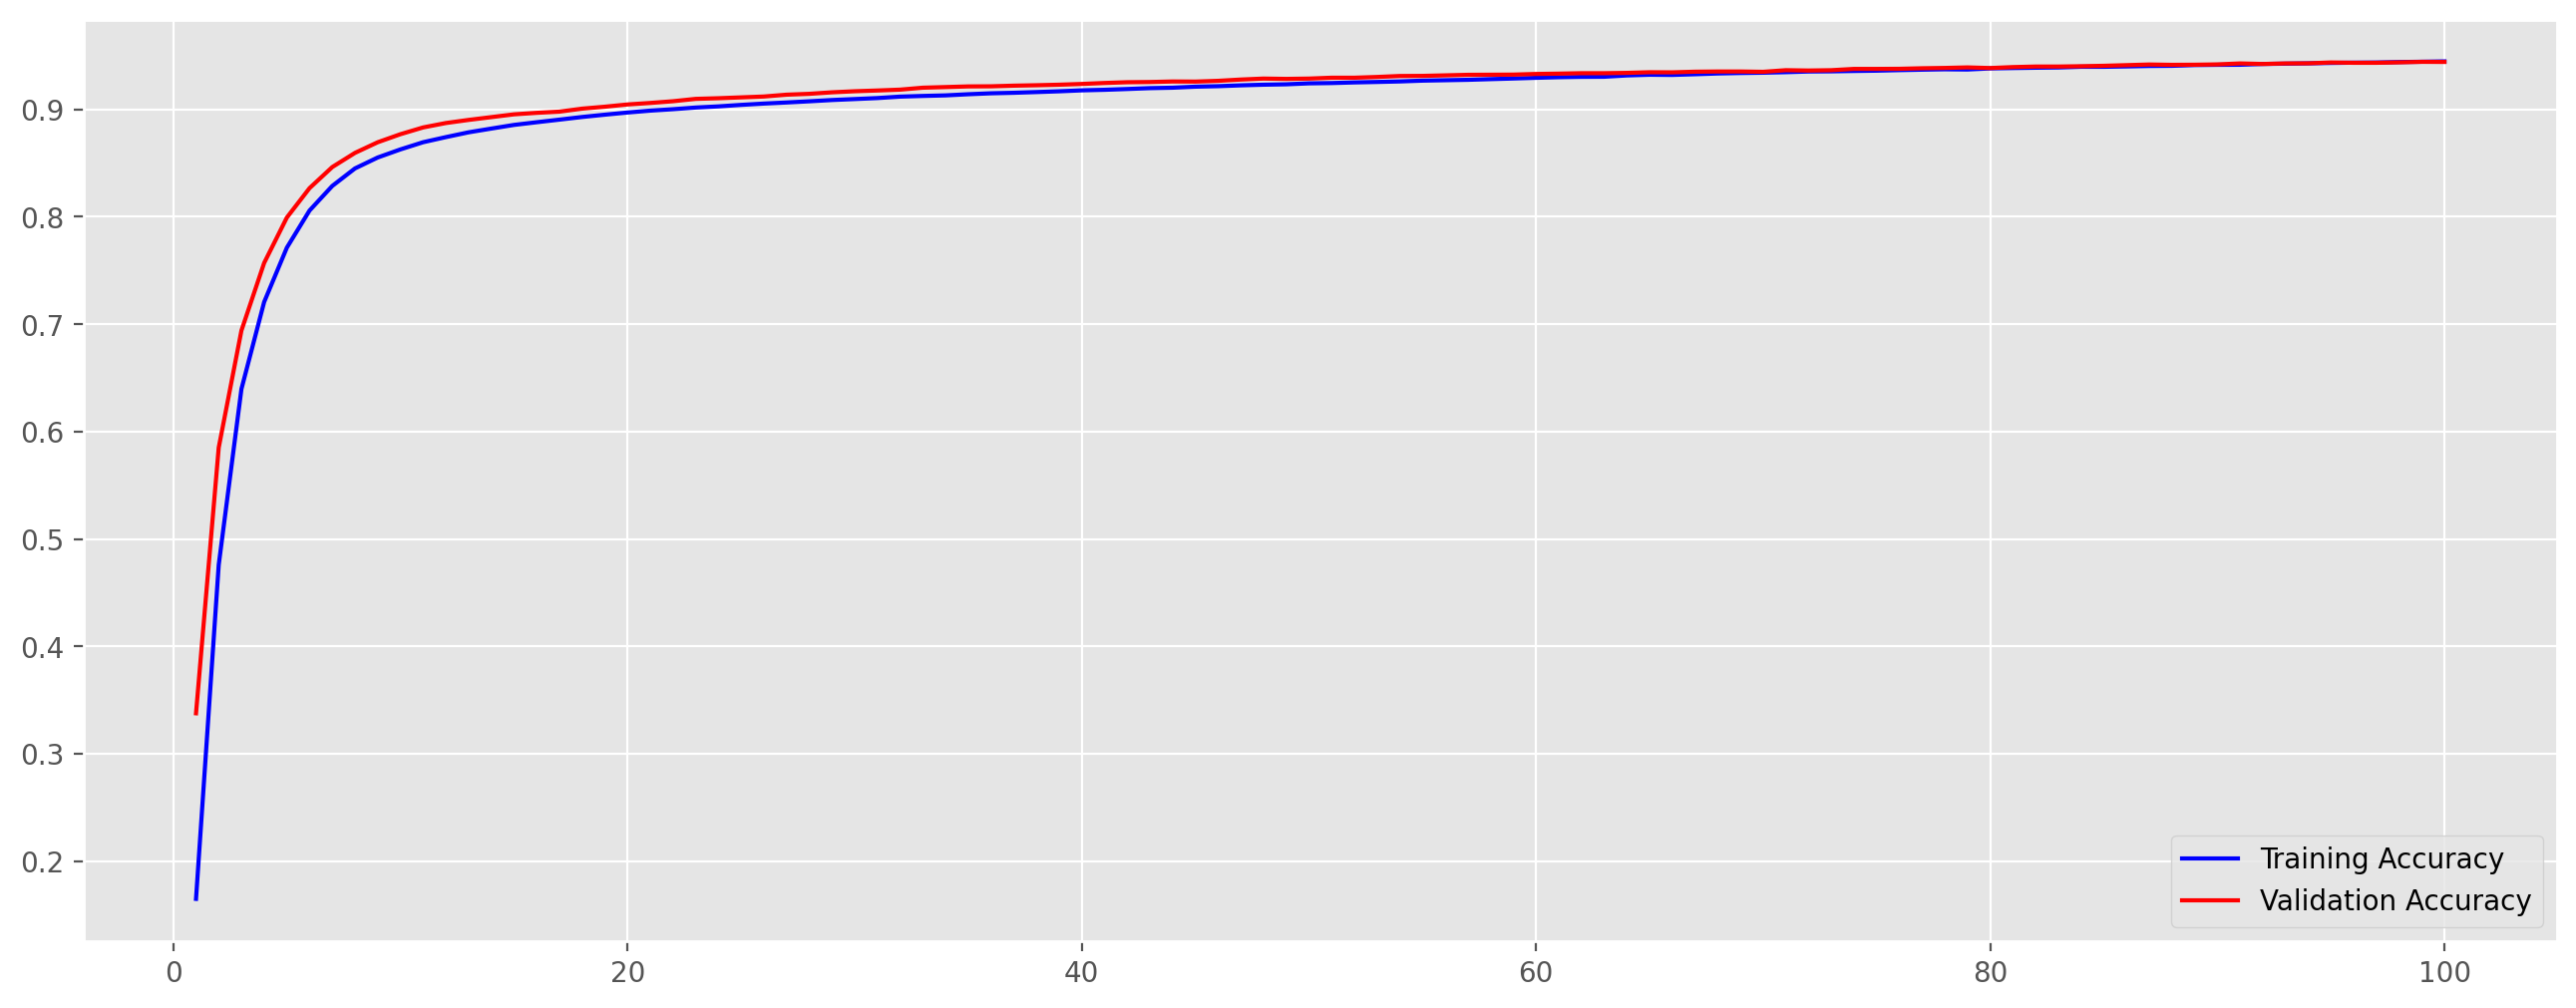

In [20]:
acc_train = history.history['accuracy']
acc_val   = history.history['val_accuracy']
num_epochs = range(1,101)

plt.figure(figsize = (16,6), dpi = 200)
plt.plot(num_epochs, acc_train, c = 'blue', label = 'Training Accuracy')
plt.plot(num_epochs, acc_val,   c = 'red', label = 'Validation Accuracy')
plt.legend()

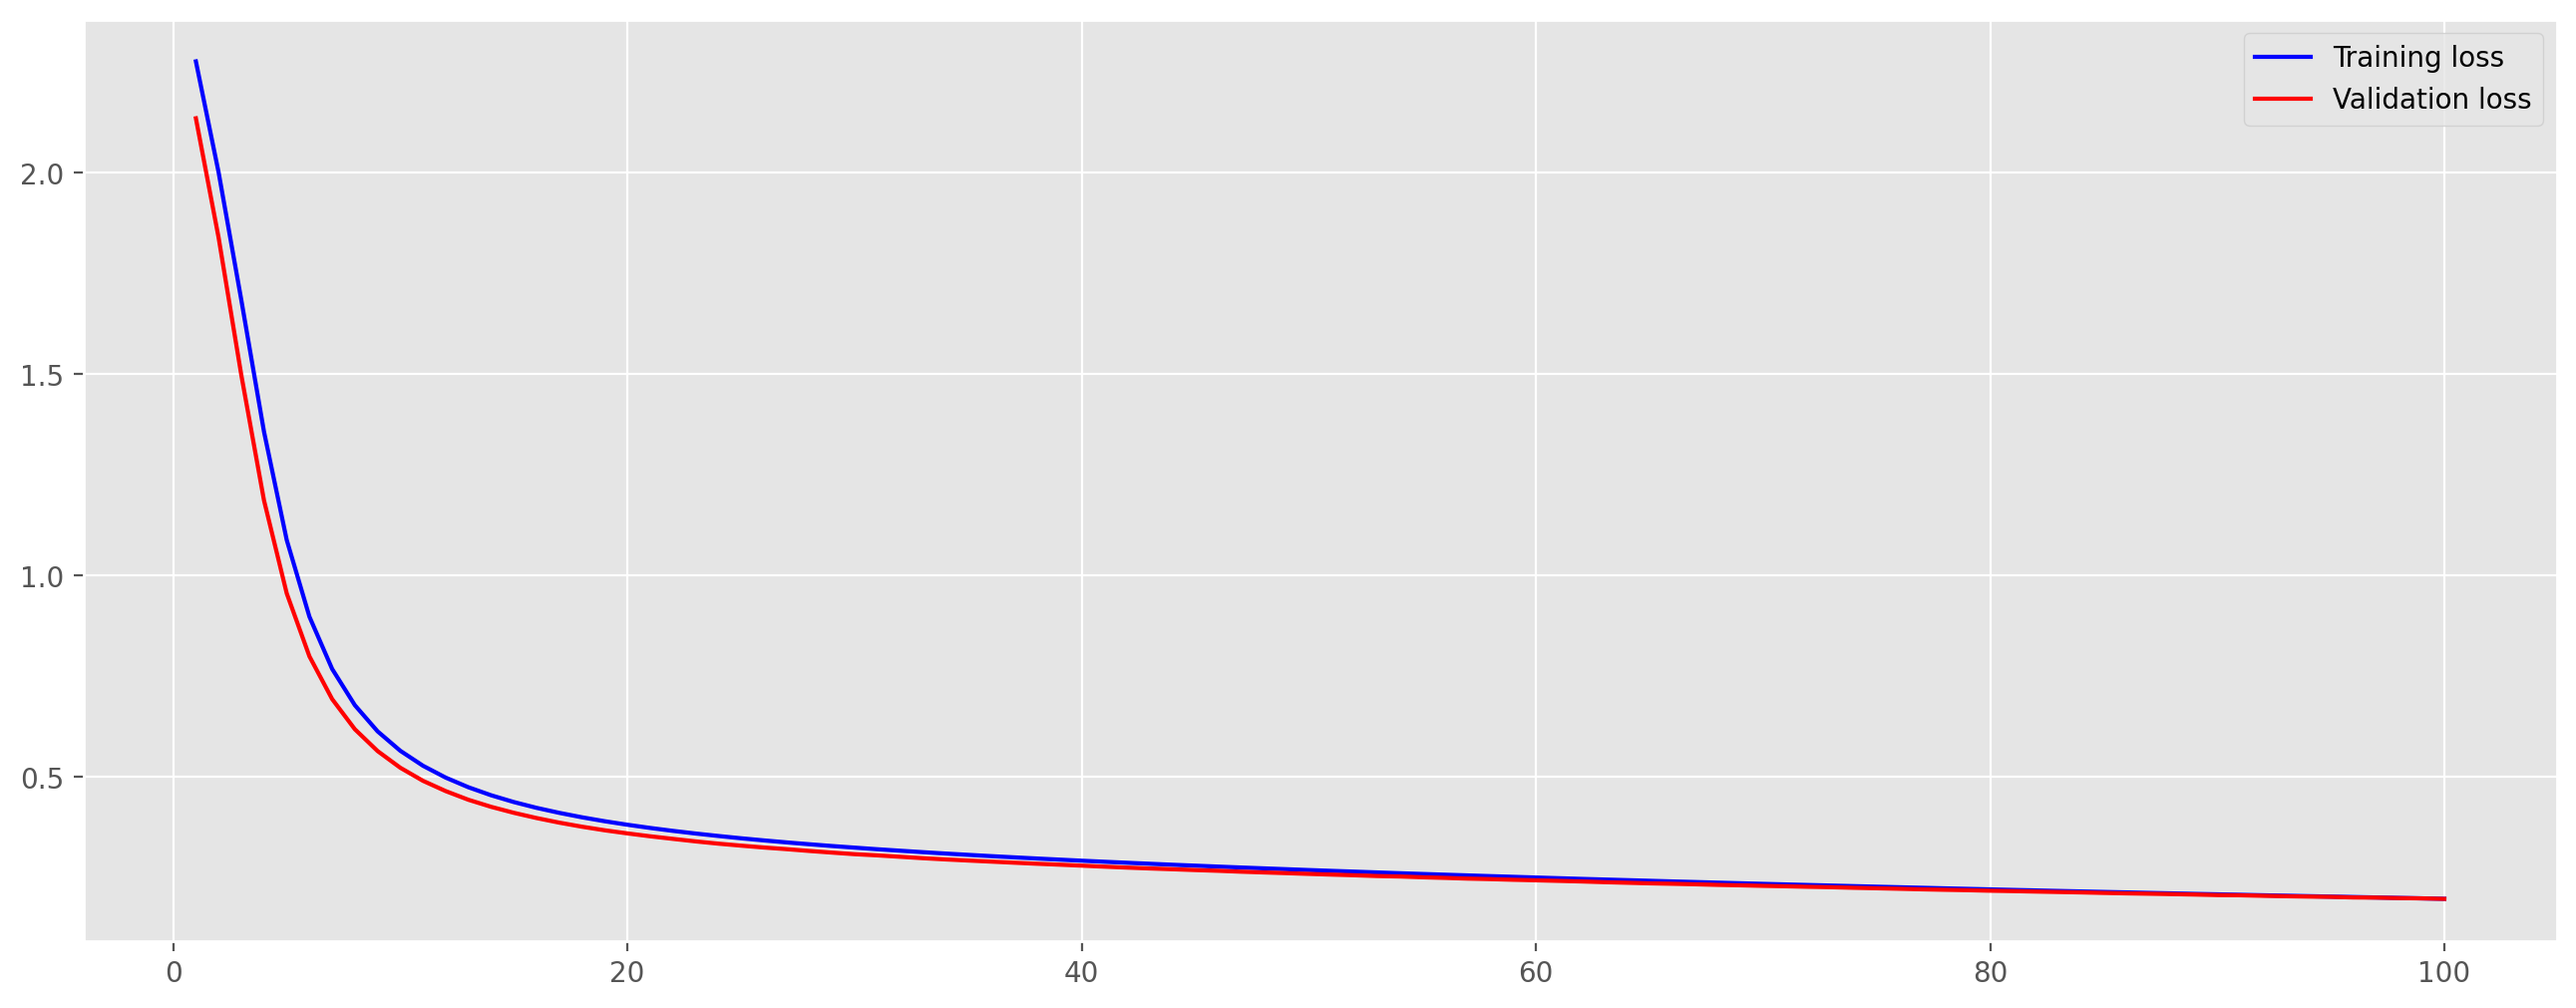

In [21]:
loss_train = history.history['loss']
loss_val   = history.history['val_loss']
num_epochs = range(1,101)

plt.figure(figsize = (16,6), dpi = 200)
plt.plot(num_epochs, loss_train, c = 'blue', label = 'Training loss')
plt.plot(num_epochs, loss_val,   c = 'red', label = 'Validation loss')
plt.legend()

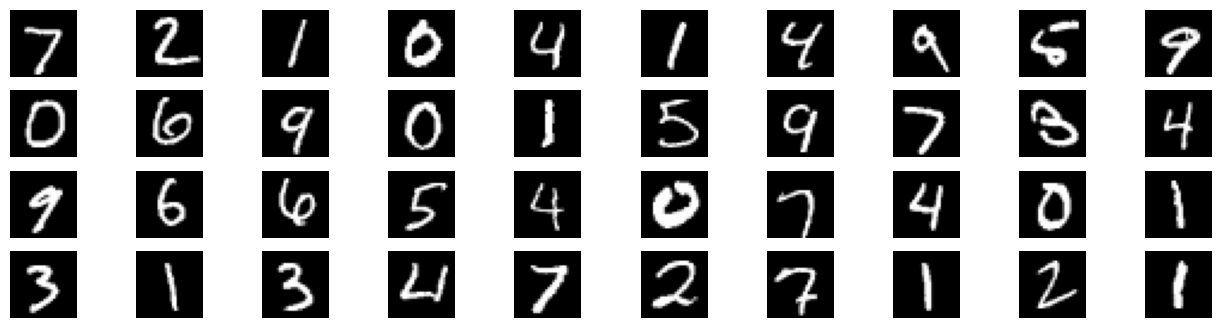

In [24]:
plt.figure(figsize = (16,4))
for i in range(40):
  plt.subplot(4,10,i+1)
  plt.axis('off')
  plt.imshow(x_test[i], cmap = 'gray')

In [27]:
np.set_printoptions(linewidth = 200)
model.predict(x_test[0:1])

1/1 [==============================] - 0s 51ms/step


array([[2.7138967e-04, 1.8699743e-07, 1.0137417e-03, 3.6308665e-03, 2.0399259e-06, 2.4587958e-04, 3.8485165e-08, 9.9425948e-01, 4.9189330e-05, 5.2721694e-04]], dtype=float32)

In [29]:
np.argmax(model.predict(x_test[:1]))

1/1 [==============================] - 0s 21ms/step


7

In [30]:
model.predict(x_test[:40])

2/2 [==============================] - 0s 8ms/step


array([[2.71389668e-04, 1.86997426e-07, 1.01374125e-03, 3.63086653e-03, 2.03992590e-06, 2.45879317e-04, 3.84852363e-08, 9.94259477e-01, 4.91893297e-05, 5.27216936e-04],
       [2.43913988e-03, 7.05667408e-05, 9.82743859e-01, 4.34172293e-03, 2.23410783e-08, 3.09506361e-03, 5.61472401e-03, 3.48701370e-08, 1.69477786e-03, 6.65319462e-08],
       [2.67450578e-05, 9.80667233e-01, 6.28724787e-03, 1.23063242e-03, 5.70023607e-04, 1.81736529e-03, 2.05196370e-03, 4.50452790e-03, 2.47430499e-03, 3.69839341e-04],
       [9.99414682e-01, 6.29723995e-10, 1.63917488e-04, 7.04548302e-06, 1.30515460e-07, 2.23041745e-04, 1.11706671e-04, 5.44818940e-05, 6.96485540e-06, 1.80971529e-05],
       [3.36300378e-04, 3.83533779e-06, 1.04791694e-03, 8.66633127e-05, 9.52534974e-01, 1.02436345e-03, 1.73295545e-03, 3.57979140e-03, 2.05890415e-03, 3.75944003e-02],
       [4.39517044e-06, 9.87739623e-01, 1.92936754e-03, 1.05563342e-03, 1.23658567e-04, 2.88838113e-04, 8.11702412e-05, 7.11584603e-03, 1.39979343e-03, 2.6

In [31]:
np.argmax(model.predict(x_test[:40]), axis = 1)

2/2 [==============================] - 0s 10ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 6, 7, 2, 7, 1, 2, 1])